# 02 · Batch QC — does an incoming batch differ from the working reference, and does it matter?

**What this notebook does.** Compares electrode-coating batches against a working reference using interpretable microstructure KPIs, states what it could and could not have detected, separates "the material changed" from "the microscope or preparation changed", and returns one of four outcomes with its evidence:

- **consistent with the working reference, within detectable limits** — never "accept" (acceptance needs tolerances we do not have);
- **investigate — batch-wide drift**;
- **investigate — localized anomaly**;
- **reject (provisional)**.

**Read first.** `docs/qc_plan.md` (method), `docs/problem_and_findings.md` (what we know about the data), `docs/assumption_register.html` (every interpretive assumption with an image), `docs/decision_log.md` (why each choice was made and the review checklist), `docs/experiment_log.md` (numbers and progress).

**Provenance.** All thresholds, KPI lists and weights below were *developed using exploratory analysis of Batches 1–3 and frozen before the unseen batch arrived*. Their hash is asserted at run time; the hash proves stability after the freeze, not independence before it.

## 0 · Configuration (frozen)

In [1]:
import os, sys, json, hashlib, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
from polaron_qc import (NM_PER_PX, BATCH_COLORS, UNSEEN_COLOR, LOW_CONTRAST_SITES, GREY_PORE_SITES, CRACKED_SITES, PRIMARY_KPIS, MATERIAL_KPIS, KPI_TRUST)
from polaron_qc import features as FE, stats as ST, decision as DE, physics as PH, report as RP, acquisition as AC
%matplotlib inline
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25, "legend.frameon": False})

CONFIG = dict(
    reference = "Batch_3",
    compare   = ["Batch_1", "Batch_2"],          # add the unseen batch folder name here when it lands (§10)
    alpha = 0.05, power = 0.80, seed = 0,
    statistic = "hl_shift",                       # verdict test statistic (D23); median_diff kept as the reported effect size
    primary_kpis = list(PRIMARY_KPIS),            # five, fixed (plan §2.0 rule 1)
    secondary_kpis = [k for k in MATERIAL_KPIS if k not in PRIMARY_KPIS],
    known_anomalous = dict(grey_pore=list(GREY_PORE_SITES), cracked=list(CRACKED_SITES), low_contrast=list(LOW_CONTRAST_SITES)),
    anomalous_handling = "flag-and-show",         # or "exclude"
    thresholds = DE.Thresholds(),                 # decision thresholds (D22)
    provenance = "developed using exploratory analysis of Batches 1–3; frozen before the unseen batch arrived",
)
FROZEN_HASH = "99d2bbcae6f3"   # frozen 2026-10-03 after the drop rehearsal (D34, E23); the assert below guards the unseen-batch run
# the hash covers every methodological choice (reference, α, power, statistic, KPI lists, flags handling, thresholds) but NOT the
# list of compared folders, so the unseen batch can be added to CONFIG["compare"] without touching anything that is frozen
cfg_hash = hashlib.sha1(json.dumps({k: (v if not hasattr(v, "hash") else v.hash()) for k, v in CONFIG.items() if k != "compare"}, sort_keys=True, default=str).encode()).hexdigest()[:12]
print("configuration hash:", cfg_hash, "| thresholds hash:", CONFIG["thresholds"].hash())
if FROZEN_HASH is not None:
    assert cfg_hash == FROZEN_HASH, f"configuration changed after freeze ({cfg_hash} != {FROZEN_HASH})"
DATA = os.path.join(ROOT, "Dataset"); FCACHE = os.path.join(ROOT, "analysis_cache", "features"); REPORTS = os.path.join(ROOT, "reports"); os.makedirs(REPORTS, exist_ok=True)

configuration hash: 99d2bbcae6f3 | thresholds hash: b4f4da2e357c


## 1 · Features

One call per batch folder (`polaron_qc.features.extract_batch`) returns four tables — sites, images, particles, 512-px patches — and caches them by content hash. Lengths are in pixels; µm are nominal at 25 nm/px. Definitions and trust levels are in the KPI catalogue (`docs/problem_and_findings.md` §4) and in `polaron_qc.KPI_TRUST`.

In [2]:
t0 = time.time()
BATCHES = {b: FE.extract_batch(os.path.join(DATA, b), cache_dir=FCACHE, verbose=False) for b in [CONFIG["reference"]] + CONFIG["compare"]}
print({b: {k: v.shape for k, v in t.items()} for b, t in BATCHES.items()}, f"\n{time.time()-t0:.0f} s")

def sites_of(b):
    """Site table with the DATA-DERIVED acquisition flags written in (same call path as build_result, D31): grey_pore from the
    batch's own BSE black level (the known list is only a cross-check on the reference), low contrast from the features."""
    t = BATCHES[b]; s = t["sites"].copy(); s["site"] = s.site.astype(str)
    s = RP.apply_derived_flags(s, RP.derive_flags(s, t["images"]))
    s["cracked_known"] = s.site.isin(CONFIG["known_anomalous"]["cracked"])      # reference-only label, never data-derived
    s["low_contrast"] = s.bright_low_contrast.astype(bool)
    return s
REF = sites_of(CONFIG["reference"]); ORD_MASK = (REF.acquisition_group == "ordinary").to_numpy()
assert set(REF.site[REF.grey_pore]) == set(CONFIG["known_anomalous"]["grey_pore"]), "data-derived grey-pore flags differ from the known reference list"
print(f"reference {CONFIG['reference']}: {len(REF)} sites, {int(ORD_MASK.sum())} ordinary, {int(REF.grey_pore.sum())} grey-pore, {int(REF.cracked_known.sum())} cracked, {int(REF.low_contrast.sum())} low-contrast")
display(REF[["site"] + CONFIG["primary_kpis"] + ["low_contrast", "grey_pore", "cracked_known"]].round(4))

{'Batch_3': {'sites': (17, 150), 'images': (51, 13), 'particles': (3567, 10), 'patches': (819, 14)}, 'Batch_1': {'sites': (7, 150), 'images': (21, 13), 'particles': (5268, 10), 'patches': (338, 14)}, 'Batch_2': {'sites': (7, 150), 'images': (21, 13), 'particles': (1612, 10), 'patches': (364, 14)}} 
0 s


reference Batch_3: 17 sites, 10 ordinary, 4 grey-pore, 3 cracked, 0 low-contrast


,site,crack_frac,pore_max_d,pore_frac,bright_frac,bright_d50,low_contrast,grey_pore,cracked_known
0,0grcilhi,0.0624,449.8357,0.1285,0.0455,149.5730,False,False,True
1,71vgq3fw,0.0107,278.2410,0.0766,0.0591,154.7238,False,True,False
2,9luzk4jm,0.0361,340.6995,0.1201,0.0569,143.3308,False,False,False
3,cfe5vt7s,0.0056,206.5828,0.0799,0.0603,177.6866,False,False,False
4,hawkfj64,0.0201,235.5260,0.0931,0.0401,121.1577,False,False,False
5,hzumfsms,0.0607,599.3722,0.1413,0.0461,136.5991,False,False,True
6,kbdh4tri,0.0081,203.9028,0.0731,0.0533,137.6530,False,True,False
7,mgxahqnk,0.0177,274.8987,0.0963,0.0643,208.7440,False,False,False
8,pl8uabbv,0.0202,355.0882,0.1044,0.0529,133.5593,False,False,False
9,ptg8lmto,0.0163,265.5002,0.0822,0.0492,137.9302,False,False,False


## 2 · Reference characterisation — how much does the reference constrain?

Batch 3 is the closest thing to a baseline we have, not a clean one: it is a single production batch with 17 sites, of which four were imaged or prepared differently (grey-pore group) and three contain large delamination-like voids. Everything below is shown **with and without** those known-anomalous sites.

- **Spread**: median and MAD per primary KPI.
- **Minimum detectable change (MDC)**: the smallest shift, in reference MADs and in KPI units, that a batch of *n* sites would be detected with 80 % power at α = 0.05 by the test used in §3. Obtained by simulation: n-site pseudo-batches drawn from the reference without replacement (D23), shifted, compared against the remaining sites.
- A null result in §3 must always be read next to the MDC: it means *not detectable at this sensitivity*, never *no change*.

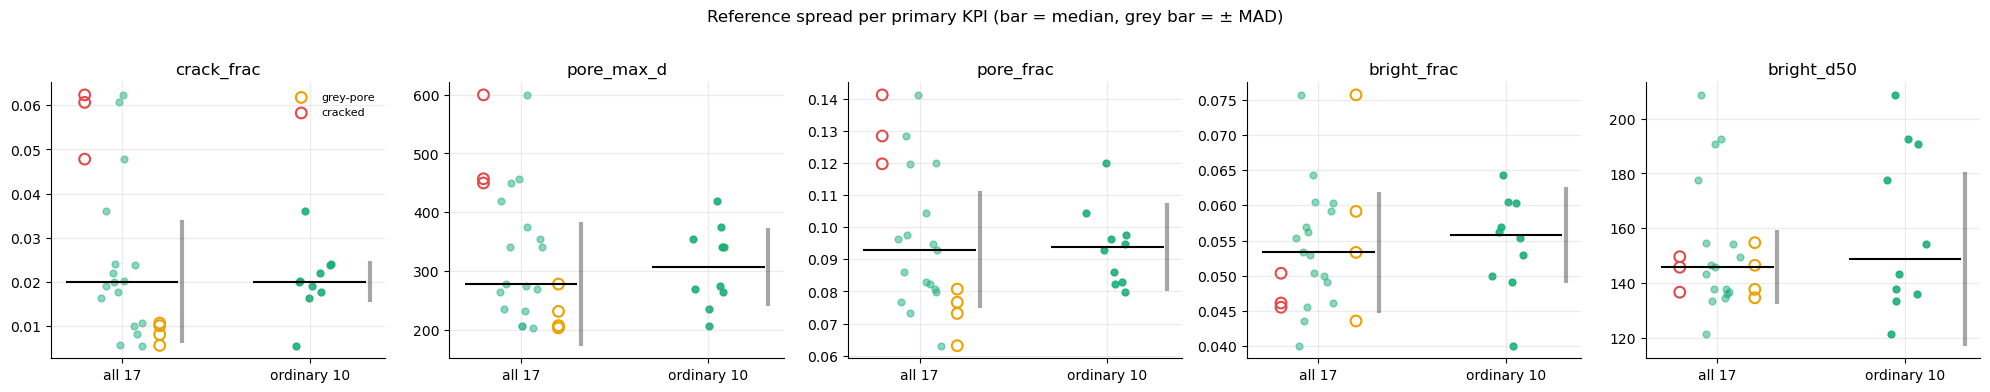

In [3]:
prim = CONFIG["primary_kpis"]; ref_all = REF; ref_ord = REF[ORD_MASK]
fig, axes = plt.subplots(1, len(prim), figsize=(4 * len(prim), 3.8))
rng = np.random.default_rng(1)
for ax, k in zip(axes, prim):
    for i, (lab, sub, alpha) in enumerate([(f"all {len(ref_all)}", ref_all, .5), (f"ordinary {len(ref_ord)}", ref_ord, .9)]):
        y = sub[k].values; x = np.full(len(y), i) + rng.uniform(-.12, .12, len(y))
        ax.scatter(x, y, s=24, color=BATCH_COLORS["Batch_3"], alpha=alpha); m, d = np.median(y), ST.mad(y)
        ax.hlines(m, i - .3, i + .3, color="k", lw=1.5); ax.vlines(i + .32, m - d, m + d, color="k", lw=3, alpha=.35)
    g = ref_all[ref_all.grey_pore]; c = ref_all[ref_all.cracked_known]
    ax.scatter(np.full(len(g), .2), g[k], s=60, facecolors="none", edgecolors=BATCH_COLORS["Batch_3 (grey-pore group)"], lw=1.5, label="grey-pore")
    ax.scatter(np.full(len(c), -.2), c[k], s=60, facecolors="none", edgecolors="#e34948", lw=1.5, label="cracked")
    ax.set_xticks([0, 1]); ax.set_xticklabels([f"all {len(ref_all)}", f"ordinary {len(ref_ord)}"]); ax.set_title(k)
axes[0].legend(fontsize=8); plt.suptitle("Reference spread per primary KPI (bar = median, grey bar = ± MAD)", y=1.02); plt.tight_layout(); plt.show()

In [4]:
# MDC per primary KPI, for the usable n of each compared batch (computed on the full usable reference; D23)
def usable_batch_n(batch_sites, k):
    return int(ST.usable_n(batch_sites, k)["n_usable"]) if "n_usable" in ST.usable_n(batch_sites, k) else int(batch_sites[k].notna().sum())
rows = []
for k in prim:
    x = REF[k].dropna().values
    for b in CONFIG["compare"]:
        n_in = usable_batch_n(sites_of(b), k)
        m = ST.mdc(x, n_in, alpha=CONFIG["alpha"], power=CONFIG["power"], test=dict(statistic=CONFIG["statistic"], n_mc=999), seed=CONFIG["seed"])
        rows.append(dict(kpi=k, batch=b, n_incoming=n_in, ref_median_all=np.median(x), ref_mad_all=ST.mad(x),
                         ref_median_ordinary=np.median(ref_ord[k]), ref_mad_ordinary=ST.mad(ref_ord[k]),
                         mdc_mad=m["mdc_mad"], mdc_abs=m.get("mdc_abs", m["mdc_mad"] * ST.mad(x)), feasible=m.get("feasible", True), design=m.get("design", "")))
MDC = pd.DataFrame(rows)
display(MDC.round(4))
if not MDC.feasible.all():
    print("MDC not available for:", MDC[~MDC.feasible][["kpi", "batch", "n_incoming", "design"]].to_string(index=False))
print("Reading: an absolute MDC larger than the reference median (e.g. crack_frac) means only a batch that more than doubles that KPI could register as batch-wide drift; the localized path (§3) exists for exactly this case.")
print("Design limit: the split-reference simulation needs ≥ 3 reference sites left after drawing n_incoming, so for an incoming batch with n ≥ n_ref − 2 usable sites the MDC is reported as 'not available' (the comparison itself still runs; E21).")

,kpi,batch,n_incoming,ref_median_all,ref_mad_all,ref_median_ordinary,ref_mad_ordinary,mdc_mad,mdc_abs,feasible,design
0,crack_frac,Batch_1,7,0.0201,0.0139,0.0201,0.0046,1.75,0.0244,True,7 sites drawn without replacement from 17 refe...
1,crack_frac,Batch_2,7,0.0201,0.0139,0.0201,0.0046,1.75,0.0244,True,7 sites drawn without replacement from 17 refe...
2,pore_max_d,Batch_1,7,278.2410,104.6864,307.7991,66.4116,1.75,183.2013,True,7 sites drawn without replacement from 17 refe...
3,pore_max_d,Batch_2,7,278.2410,104.6864,307.7991,66.4116,1.75,183.2013,True,7 sites drawn without replacement from 17 refe...
4,pore_frac,Batch_1,7,0.0931,0.0183,0.0939,0.0136,2.00,0.0366,True,7 sites drawn without replacement from 17 refe...
5,pore_frac,Batch_2,7,0.0931,0.0183,0.0939,0.0136,2.00,0.0366,True,7 sites drawn without replacement from 17 refe...
6,bright_frac,Batch_1,5,0.0533,0.0086,0.0558,0.0068,1.75,0.0151,True,5 sites drawn without replacement from 17 refe...
7,bright_frac,Batch_2,7,0.0533,0.0086,0.0558,0.0068,1.50,0.0130,True,7 sites drawn without replacement from 17 refe...
8,bright_d50,Batch_1,5,145.7270,13.5330,148.7573,31.7259,3.00,40.5989,True,5 sites drawn without replacement from 17 refe...
9,bright_d50,Batch_2,7,145.7270,13.5330,148.7573,31.7259,2.50,33.8325,True,7 sites drawn without replacement from 17 refe...


Reading: an absolute MDC larger than the reference median (e.g. crack_frac) means only a batch that more than doubles that KPI could register as batch-wide drift; the localized path (§3) exists for exactly this case.
Design limit: the split-reference simulation needs ≥ 3 reference sites left after drawing n_incoming, so for an incoming batch with n ≥ n_ref − 2 usable sites the MDC is reported as 'not available' (the comparison itself still runs; E21).


### 2b · Reference-split diagnostics (internal)

Repeated random splits of the reference into *n* pseudo-incoming sites versus the rest, run through the same comparison and decision as §3–§4. Outcomes are tallied separately — statistical drift alerts, local flags, quality abstentions — and the split (7 vs 10) is smaller than the real comparison (7 vs 17), so this is a diagnostic with its own uncertainty, not a verified false-alarm rate. *(Filled in after §4 is wired; placeholder.)*

In [5]:
# placeholder — wired after the decision pipeline function exists (see §4)
SPLIT_DIAG = None

## 3 · Pairwise comparison

Each compared batch goes through one call, `polaron_qc.report.build_result`, which runs the comparison engine, the decision layer and the leave-one-site-out stability check and collects the ML, physics and acquisition evidence. Per KPI: robust shift in reference MADs, an approximate bootstrap interval, a site-level permutation p-value on the Hodges–Lehmann shift (exact enumeration at these n), Holm-adjusted across the five primary KPIs only. Multivariate: energy distance on the primary KPIs with site-label permutation and the scaling re-fitted inside every permutation. Usable n per KPI (after quality flags) is what enters every test.

In [6]:
from polaron_qc import report as RP, acquisition as AC
%matplotlib inline
RP_CONFIG = dict(alpha=CONFIG["alpha"], power=CONFIG["power"], seed=CONFIG["seed"], statistic=CONFIG["statistic"], primary=CONFIG["primary_kpis"])
RESULTS = {}
for b in CONFIG["compare"]:
    t0 = time.time()
    RESULTS[b] = RP.build_result(os.path.join(DATA, CONFIG["reference"]), os.path.join(DATA, b), config=RP_CONFIG, cache_dir=FCACHE, verbose=False)
    print(f"{b}: built in {time.time()-t0:.0f} s → {RESULTS[b]['verdict']['verdict']}")

show_cols = ["kpi", "n_ref_usable", "n_batch_usable", "ref_median", "batch_median", "shift_mad", "ci_low", "ci_high", "p_perm", "p_method", "n_perm", "p_holm", "direction"]
for b, res in RESULTS.items():
    cmp = res["compare"]
    print(f"\n### {b} vs {CONFIG['reference']} — primary KPIs")
    display(cmp[cmp.is_primary][show_cols].round(4).reset_index(drop=True))
    e = res["energy"]; print(f"energy distance on primary KPIs: statistic {e['statistic']:.3f}, p = {e['p']:.3f} ({e.get('n_perm')} permutations)")

Batch_1: built in 60 s → consistent with working reference (within detectable limits)


Batch_2: built in 70 s → consistent with working reference (within detectable limits)

### Batch_1 vs Batch_3 — primary KPIs


,kpi,n_ref_usable,n_batch_usable,ref_median,batch_median,shift_mad,ci_low,ci_high,p_perm,p_method,n_perm,p_holm,direction
0,crack_frac,17,7,0.0201,0.0218,0.1217,-2.0914,2.1782,0.9118,exact,346104,1.0000,none
1,pore_max_d,17,7,278.2410,282.6652,0.0423,-1.3153,1.0054,0.2575,exact,346104,1.0000,none
2,pore_frac,17,7,0.0931,0.0921,-0.0549,-1.8585,1.9431,0.5865,exact,346104,1.0000,none
3,bright_frac,17,5,0.0533,0.0602,0.7966,-1.3954,2.3237,0.4007,exact,26334,1.0000,none
4,bright_d50,17,5,145.7270,165.3143,1.4474,-0.1119,7.8446,0.0715,exact,26334,0.3577,none


energy distance on primary KPIs: statistic 1.700, p = 0.404 (5000 permutations)

### Batch_2 vs Batch_3 — primary KPIs


,kpi,n_ref_usable,n_batch_usable,ref_median,batch_median,shift_mad,ci_low,ci_high,p_perm,p_method,n_perm,p_holm,direction
0,crack_frac,17,7,0.0201,0.0145,-0.3994,-2.7759,0.5127,0.2171,exact,346104,0.6512,none
1,pore_max_d,17,7,278.2410,253.5867,-0.2355,-1.1568,0.4064,0.1108,exact,346104,0.5542,none
2,pore_frac,17,7,0.0931,0.0754,-0.9632,-1.6854,0.0994,0.1423,exact,346104,0.5693,none
3,bright_frac,17,7,0.0533,0.0552,0.2154,-2.1510,1.3308,0.9667,exact,346104,0.9667,none
4,bright_d50,17,7,145.7270,163.8250,1.3373,-0.5071,5.6923,0.3139,exact,346104,0.6512,none


energy distance on primary KPIs: statistic 1.535, p = 0.343 (5000 permutations)


### 3b · Secondary KPIs (descriptive, uncorrected)

In [7]:
for b, res in RESULTS.items():
    cmp = res["compare"]; sec = cmp[~cmp.is_primary].copy(); sec["trust"] = sec.kpi.map(KPI_TRUST)
    print(f"\n### {b} — secondary KPIs (no multiplicity correction; never drive a verdict)")
    display(sec[["kpi", "trust", "n_ref_usable", "n_batch_usable", "shift_mad", "ci_low", "ci_high", "p_perm", "direction"]].round(4).reset_index(drop=True))


### Batch_1 — secondary KPIs (no multiplicity correction; never drive a verdict)


,kpi,trust,n_ref_usable,n_batch_usable,shift_mad,ci_low,ci_high,p_perm,direction
0,crack_count_per_Mpx,high,17,7,0.3108,-1.1932,3.1599,0.5874,none
1,pore_d50,high,17,7,0.1599,-0.7361,2.1484,0.7293,none
2,pore_d90,high,17,7,-0.2220,-1.2601,1.2205,0.7085,none
3,pore_elong,high,17,7,-0.1360,-2.3090,1.3904,0.1537,none
4,pore_count_per_Mpx,high,17,7,0.4600,-0.1970,8.9323,0.0299,none
5,bright_count_per_Mpx,high,17,5,0.4691,-0.8230,2.3943,0.5460,none
6,bright_d10,high,17,5,0.2084,-1.5103,1.3877,0.9421,none
7,bright_d90,high,17,5,-1.0562,-2.3230,1.7749,0.2264,none
8,bright_circ,high,17,5,0.2209,-2.1427,2.3451,0.8735,none
9,bright_solidity,high,17,5,0.0896,-1.2685,2.2941,0.9646,none



### Batch_2 — secondary KPIs (no multiplicity correction; never drive a verdict)


,kpi,trust,n_ref_usable,n_batch_usable,shift_mad,ci_low,ci_high,p_perm,direction
0,crack_count_per_Mpx,high,17,7,-0.3278,-2.1588,1.2647,0.3470,none
1,pore_d50,high,17,7,-0.2531,-1.8872,0.7383,0.4904,none
2,pore_d90,high,17,7,-0.3905,-1.3819,0.5880,0.3291,none
3,pore_elong,high,17,7,-0.0973,-2.1099,1.0713,0.3117,none
4,pore_count_per_Mpx,high,17,7,-2.2238,-8.4696,0.1126,0.0131,none
5,bright_count_per_Mpx,high,17,7,-0.0953,-0.8651,2.9940,0.8130,none
6,bright_d10,high,17,7,0.1950,-1.4902,1.5862,0.9885,none
7,bright_d90,high,17,7,0.1994,-0.7457,2.2287,0.8684,none
8,bright_circ,high,17,7,-0.4558,-2.5312,1.2811,0.4203,none
9,bright_solidity,high,17,7,-0.3501,-2.0341,1.7264,0.4014,none


### 3c · Per-site drift — batch-wide or a few sites?

Robust diagonal-MAD distance of every site to the reference centre on the primary KPIs; reference sites are scored leave-one-out so they are out of sample like the batch sites. Percentile = rank within the reference distribution.

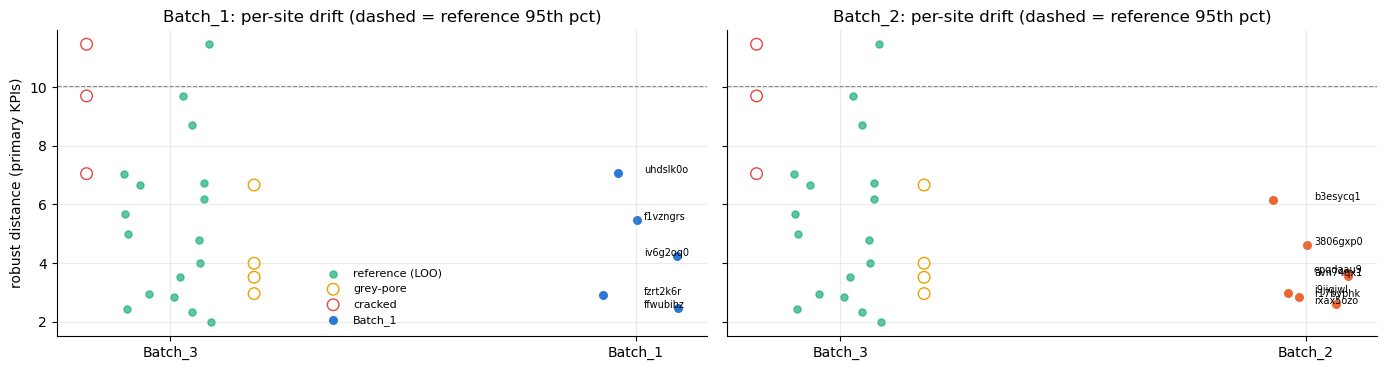

Batch_1: 0 of 5 sites beyond the reference 95th percentile; sites with no drift score (unusable bright KPIs): ['4ih2ggld', '5n1q8atc']
Batch_2: 0 of 7 sites beyond the reference 95th percentile; sites with no drift score (unusable bright KPIs): []


In [8]:
fig, axes = plt.subplots(1, len(RESULTS), figsize=(7 * len(RESULTS), 3.8), sharey=True)
for ax, (b, res) in zip(np.atleast_1d(axes), RESULTS.items()):
    d = res["drift"]
    ref_d = d[d.group == "reference"]; bat_d = d[d.group == "batch"]
    is_grey = ref_d.site.isin(GREY_PORE_SITES); is_cr = ref_d.site.isin(CRACKED_SITES)
    ax.scatter(np.zeros(len(ref_d)) + np.random.default_rng(0).uniform(-.1, .1, len(ref_d)), ref_d.distance, s=26, color=BATCH_COLORS.get(CONFIG["reference"], UNSEEN_COLOR), alpha=.7, label="reference (LOO)")
    ax.scatter(np.zeros(is_grey.sum()) + .18, ref_d[is_grey].distance, s=70, facecolors="none", edgecolors=BATCH_COLORS["Batch_3 (grey-pore group)"], label="grey-pore")
    ax.scatter(np.zeros(is_cr.sum()) - .18, ref_d[is_cr].distance, s=70, facecolors="none", edgecolors="#e34948", label="cracked")
    ax.scatter(np.ones(len(bat_d)) + np.random.default_rng(1).uniform(-.1, .1, len(bat_d)), bat_d.distance, s=30, color=BATCH_COLORS.get(b, UNSEEN_COLOR), label=b)
    for _, r in bat_d.iterrows(): ax.annotate(r.site, (1, r.distance), fontsize=7, xytext=(6, 0), textcoords="offset points")
    ax.axhline(np.percentile(ref_d.distance, 95), color="#888", ls="--", lw=.8); ax.set_xticks([0, 1]); ax.set_xticklabels([CONFIG["reference"], b]); ax.set_title(f"{b}: per-site drift (dashed = reference 95th pct)")
np.atleast_1d(axes)[0].set_ylabel("robust distance (primary KPIs)"); np.atleast_1d(axes)[0].legend(fontsize=8); plt.tight_layout(); plt.show()
for b, res in RESULTS.items():
    d = res["drift"]; bd = d[d.group == "batch"]
    print(f"{b}: {int((bd.percentile_in_ref > 95).sum())} of {len(bd)} sites beyond the reference 95th percentile; sites with no drift score (unusable bright KPIs): {sorted(set(sites_of(b).site) - set(bd.site))}")

### 3d · Local-anomaly evidence flags

Per-site exceedance of the **ordinary-reference maximum** on the extreme-semantics KPIs (`decision.LOCAL_KPIS`). Under an i.i.d. null, at least one of 7 sites exceeds the max of 10 with probability 7/17 ≈ 41 % on a single KPI, so a flag is evidence, not a defect. A flag is promoted only with a severity margin ≥ 1 MAD of the reference per-site values, a reliable measurement on that site, and a reviewed image. Exceedances on batch-mean KPIs are listed separately as outlying sites.

In [9]:
for b, res in RESULTS.items():
    cb = res["check_b"]
    print(f"\n### {b}: {cb['n_sites_flagged']} site(s) flagged · {cb['n_sites_pending']} pending image review · {cb['n_sites_credible']} credible · i.i.d. flag probability {ST.iid_flag_probability(len(res['ordinary_ref_sites']), res['meta']['n_sites_batch']):.2f}")
    if cb["flags"]: display(pd.DataFrame(cb["flags"]).round(4))
    if cb["descriptive_flags"]: print("outlying sites on batch-mean KPIs (not localized defects):"); display(pd.DataFrame(cb["descriptive_flags"]).round(4))


### Batch_1: 1 site(s) flagged · 0 pending image review · 0 credible · i.i.d. flag probability 0.41


,site,kpi,value,ref_max,margin_in_mad,severity_ok,measurement_reliable,measurement_note,image_reviewed,review_status,promotable
0,4ih2ggld,crack_frac,0.0373,0.0361,0.2716,False,True,ok,None,unreviewed,True


outlying sites on batch-mean KPIs (not localized defects):


,site,kpi,value,ref_max,margin_in_mad,note
0,f1vzngrs,bright_frac,0.067,0.0643,0.3962,"batch-mean KPI: outlying site, not a localized..."



### Batch_2: 0 site(s) flagged · 0 pending image review · 0 credible · i.i.d. flag probability 0.41
outlying sites on batch-mean KPIs (not localized defects):


,site,kpi,value,ref_max,margin_in_mad,note
0,b3esycq1,bright_frac,0.0787,0.0643,2.1206,"batch-mean KPI: outlying site, not a localized..."


### 3e · Batch 1 vs Batch 2 (7 vs 7)

Reported because the task is differentiation, with the caveat that at 7 vs 7 the smallest attainable two-sided p is 2/3432 ≈ 0.0006 and power is low; most KPIs will return "cannot distinguish".

In [10]:
b1, b2 = sites_of("Batch_1"), sites_of("Batch_2")
c12 = ST.compare_kpis(b1, b2, CONFIG["primary_kpis"] + CONFIG["secondary_kpis"], primary=CONFIG["primary_kpis"], seed=CONFIG["seed"], statistic=CONFIG["statistic"], alpha=CONFIG["alpha"])
display(c12[c12.is_primary][show_cols].round(4).reset_index(drop=True))
X1 = RP._primary_matrix(RP._mask_unusable(b1, CONFIG["primary_kpis"]), CONFIG["primary_kpis"]); X2 = RP._primary_matrix(RP._mask_unusable(b2, CONFIG["primary_kpis"]), CONFIG["primary_kpis"])
e12 = ST.energy_distance_test(X1.dropna().values, X2.dropna().values, weights=PH.weights_vector(CONFIG["primary_kpis"]), n_mc=5000, seed=CONFIG["seed"])
print(f"energy distance Batch_1 (n={len(X1.dropna())}) vs Batch_2 (n={len(X2.dropna())}): {e12['statistic']:.3f}, p = {e12['p']:.3f}")

,kpi,n_ref_usable,n_batch_usable,ref_median,batch_median,shift_mad,ci_low,ci_high,p_perm,p_method,n_perm,p_holm,direction
0,crack_frac,7,7,0.0218,0.0145,-0.4526,-4.3724,0.7685,0.3625,exact,3432,1.0000,none
1,pore_max_d,7,7,282.6652,253.5867,-0.3847,-3.4417,5.6977,0.4633,exact,3432,1.0000,none
2,pore_frac,7,7,0.0921,0.0754,-1.1196,-4.3199,2.8521,0.1871,exact,3432,0.9353,none
3,bright_frac,5,7,0.0602,0.0552,-0.5496,-20.4565,0.4929,0.5884,exact,792,1.0000,none
4,bright_d50,5,7,165.3143,163.8250,-0.1057,-48.6697,13.7890,0.2639,exact,792,1.0000,none


energy distance Batch_1 (n=5) vs Batch_2 (n=7): 2.017, p = 0.728


## 4 · ML corroboration (never the sole driver)

Two members. A grouped-cross-validated L1 logistic regression on **material KPIs only** (sites are the groups and carry equal weight; the null is a site-level label permutation) drives Check A(iv). Since D30 it is **run inside `build_result` on the site tables** (and refit in every leave-one-site-out fold), so an unseen batch needs no pre-computed ML cache for Check A(iv); the cached material run, where present, is kept beside it as `material_cached` for comparison. The same classifier with the acquisition flag `etd_boundary_sharpness` included is shown as acquisition evidence because that one flag carries the whole Batch 1 vs Batch 3 separation (E06). DINOv2 patch-embedding novelty is exploratory: on this data it tracks acquisition variables (E07) and can only raise an evidence flag.

In [11]:
rows = []
for b, res in RESULTS.items():
    for lab, d in [("material only, in-pipeline (drives A iv)", res["c2st_material"]), ("material only, cached pre-run (comparison)", res["c2st_extra"].get("material_cached")), ("flag-inclusive (acquisition evidence)", res["c2st_flag_inclusive"])]:
        if d: rows.append(dict(batch=b, run=lab, auc=d["auc"], null_lo=(d.get("null_band") or [np.nan, np.nan])[0], null_hi=(d.get("null_band") or [np.nan, np.nan])[1], p=d["p"], n_perm=d.get("n_perm"), selected=", ".join(d["coef"][d["coef"].selected].feature.tolist()) if "selected" in d["coef"] else ""))
display(pd.DataFrame(rows).round(3))
for b, res in RESULTS.items():
    nv = res.get("novelty")
    if nv and isinstance(nv.get("per_site"), pd.DataFrame):
        ps = nv["per_site"]; print(f"\n{b} novelty per site (percentile within reference LOO; exceedance of the LOO max has ≈ {res['meta']['n_sites_batch']/(res['meta']['n_sites_ref']+res['meta']['n_sites_batch']):.0%} i.i.d. probability):")
        display(ps[[c for c in ["site", "novelty_median", "pct_median", "exceeds_ref_loo_max"] if c in ps]].round(2))
    if nv and isinstance(nv.get("correlates"), pd.DataFrame):
        print("top novelty correlates (what the embedding is tracking):"); display(nv["correlates"].head(6).round(3))

,batch,run,auc,null_lo,null_hi,p,n_perm,selected
0,Batch_1,"material only, in-pipeline (drives A iv)",0.588,0.168,0.832,0.299,200,"bright_count_per_Mpx, bright_d50, pore_max_d"
1,Batch_1,"material only, cached pre-run (comparison)",0.513,0.176,0.756,0.458,200,"bright_count_per_Mpx, bright_d50, pore_max_d"
2,Batch_1,flag-inclusive (acquisition evidence),0.790,0.192,0.782,0.030,200,"etd_boundary_sharpness, bright_count_per_Mpx, ..."
3,Batch_2,"material only, in-pipeline (drives A iv)",0.588,0.159,0.807,0.294,200,"pore_frac, etd_crack_density_particles, corr_l..."
4,Batch_2,"material only, cached pre-run (comparison)",0.613,0.143,0.849,0.264,200,"pore_frac, etd_crack_density_particles, corr_l..."
5,Batch_2,flag-inclusive (acquisition evidence),0.613,0.151,0.849,0.244,200,"etd_crack_density_particles, pore_frac, corr_l..."



Batch_1 novelty per site (percentile within reference LOO; exceedance of the LOO max has ≈ 29% i.i.d. probability):


,site,novelty_median,pct_median,exceeds_ref_loo_max
1,4ih2ggld,16.97,100.00,True
2,5n1q8atc,16.99,100.00,True
6,f1vzngrs,16.61,100.00,True
7,ffwubibz,15.25,76.47,False
8,fzrt2k6r,15.49,82.35,False
10,iv6g2oq0,15.11,64.71,False
13,uhdslk0o,15.57,82.35,False


top novelty correlates (what the embedding is tracking):


,variable,kind,rho,p,n
0,bse_std,acquisition,0.438,0.014,31
1,etd_curtain_frac,acquisition,-0.438,0.014,31
2,flag_low_contrast,acquisition,0.426,0.017,31
3,bright_low_contrast,acquisition,0.426,0.017,31
4,bse_p1,acquisition,-0.397,0.027,31
5,etd_curtain_anisotropy,acquisition,0.333,0.067,31



Batch_2 novelty per site (percentile within reference LOO; exceedance of the LOO max has ≈ 29% i.i.d. probability):


,site,novelty_median,pct_median,exceeds_ref_loo_max
0,3806gxp0,15.43,82.35,False
3,avn74qx1,15.76,82.35,False
4,b3esycq1,15.80,82.35,False
5,epqdaau9,15.12,64.71,False
9,i9jiqjwl,15.21,76.47,False
11,r17byphk,14.48,11.76,False
12,rxax5ozo,14.63,35.29,False


top novelty correlates (what the embedding is tracking):


,variable,kind,rho,p,n
0,bse_std,acquisition,0.438,0.014,31
1,etd_curtain_frac,acquisition,-0.438,0.014,31
2,flag_low_contrast,acquisition,0.426,0.017,31
3,bright_low_contrast,acquisition,0.426,0.017,31
4,bse_p1,acquisition,-0.397,0.027,31
5,etd_curtain_anisotropy,acquisition,0.333,0.067,31


## 5 · Sensitivity to acquisition adjustment

Three views of each comparison: unadjusted; stratified to ordinary acquisition groups on both sides; adjusted by residualising every KPI on three a-priori acquisition covariates (bright-phase separation, BSE black level, ETD boundary sharpness) with the regression re-fitted inside every permutation. This is a sensitivity analysis, not attribution. On this reference the adjustment **amplifies** the shift because the covariates encode Batch 3's own sub-populations (D26); negative attenuation is read as "not explained away", nothing more. Since D30 the three views are computed **inside `build_result`** and their attenuation enters the verdict: a drift reject is withheld when no view is available (E21). Alongside: the three-channel agreement pattern per site.

In [12]:
ACQ = {b: RESULTS[b]["acquisition"] for b in CONFIG["compare"]}
flags_all = pd.concat([RESULTS[b]["flags_ref"] for b in CONFIG["compare"]][:1] + [RESULTS[b]["flags_batch"] for b in CONFIG["compare"]], ignore_index=True)
for b in CONFIG["compare"]:
    tv = ACQ[b]
    if not (isinstance(tv, dict) and "unadjusted" in tv):
        print(f"\n### {b}: acquisition views not available ({tv}); drift reject withheld"); continue
    rows = []
    for view in ["unadjusted", "stratified", "adjusted"]:
        e = (tv[view].get("energy") if view != "adjusted" else tv[view].get("energy_adjusted")) if tv.get(view) else None
        rows.append(dict(view=view, energy=None if not e else round(e["statistic"], 3), p=None if not e else round(e["p"], 3), n_ref=tv[view].get("n_ref_kept", tv[view].get("n_ref")), n_batch=tv[view].get("n_batch_kept", tv[view].get("n_batch")), note=tv[view].get("reason", "")))
    att = RESULTS[b]["verdict"]["attenuation"]
    print(f"\n### {b}: three views (from build_result) — attenuation stratified {att['stratified']:+.2f}, adjusted {att['adjusted']:+.2f}, available = {att['available']}")
    display(pd.DataFrame(rows))
agree = AC.three_channel_agreement(pd.concat([REF] + [sites_of(b) for b in CONFIG["compare"]]), pd.concat([BATCHES[x]["images"] for x in [CONFIG["reference"]] + CONFIG["compare"]]))
print("three-channel agreement — sites with a pattern other than 'none':")
display(agree[agree.pattern != "none"][[c for c in ["batch", "site", "pattern", "intensity_disagreement", "texture_disagreement"] if c in agree]].round(2))
print("\nData-derived flags written into the site tables before any statistic ran (grey pore = raised BSE black level; low contrast from features):")
display(flags_all[["batch", "site", "acquisition_group", "grey_pore", "grey_pore_source", "bright_low_contrast", "raised_black_level", "bse_p1"]].sort_values(["batch", "acquisition_group"]).reset_index(drop=True))


### Batch_1: three views (from build_result) — attenuation stratified +0.28, adjusted -1.39, available = True


,view,energy,p,n_ref,n_batch,note
0,unadjusted,1.700,0.404,NaN,NaN,
1,stratified,1.220,0.830,10.0,5.0,None
2,adjusted,4.059,0.078,NaN,NaN,



### Batch_2: three views (from build_result) — attenuation stratified -0.73, adjusted -3.01, available = True


,view,energy,p,n_ref,n_batch,note
0,unadjusted,1.535,0.343,NaN,NaN,
1,stratified,2.654,0.156,10.0,7.0,None
2,adjusted,6.157,0.015,NaN,NaN,


three-channel agreement — sites with a pattern other than 'none':

,batch,site,pattern,intensity_disagreement,texture_disagreement
1,Batch_3,71vgq3fw,intensity-only shift,2.05,0.60
6,Batch_3,kbdh4tri,intensity-only shift,2.20,0.47
10,Batch_3,tuy3zymq,intensity-only shift,2.18,0.70
15,Batch_3,x7u69zsw,intensity-only shift,2.14,0.21
24,Batch_2,3806gxp0,intensity-only shift,1.52,0.34
25,Batch_2,avn74qx1,intensity-only shift,1.39,1.12



Data-derived flags written into the site tables before any statistic ran (grey pore = raised BSE black level; low contrast from features):


,batch,site,acquisition_group,grey_pore,grey_pore_source,bright_low_contrast,raised_black_level,bse_p1
0,Batch_1,4ih2ggld,low_contrast,False,,True,False,0
1,Batch_1,5n1q8atc,low_contrast,False,,True,False,0
2,Batch_1,f1vzngrs,ordinary,False,,False,False,0
3,Batch_1,ffwubibz,ordinary,False,,False,False,0
4,Batch_1,fzrt2k6r,ordinary,False,,False,False,0
5,Batch_1,iv6g2oq0,ordinary,False,,False,False,0
6,Batch_1,uhdslk0o,ordinary,False,,False,False,0
7,Batch_2,3806gxp0,ordinary,False,,False,False,0
8,Batch_2,avn74qx1,ordinary,False,,False,False,0
9,Batch_2,b3esycq1,ordinary,False,,False,False,0


## 6 · Physics reading (qualitative, relative) and measurement sanity

Consequence weights (ordinal) enter the multivariate test and the decision. Qualitative statements are emitted only for driver KPIs and only when the shift exceeds the ±5-gray-level threshold band for that KPI. Sanity checks: phase fractions sum to one; the ±5-level band per site; the dataset-level porosity note (open macro-pore fraction 6–14 % is consistent with unresolved porosity in the binder network being counted as solid — segmentation and preparation remain alternatives); no site has a 2-D top-to-bottom macro-pore path, so no tortuosity index is reported.

In [13]:
W = pd.DataFrame({"kpi": CONFIG["primary_kpis"] + CONFIG["secondary_kpis"]}); W["consequence_weight"] = W.kpi.map(PH.CONSEQUENCE_WEIGHTS); W["trust"] = W.kpi.map(KPI_TRUST); W["rationale"] = W.kpi.map(PH.CONSEQUENCE_RATIONALE)
display(W)
bands = pd.read_csv(os.path.join(ROOT, "analysis_cache", "acquisition_sites.csv"))
print("±5-level threshold band (relative) by batch — median pore_frac / bright_frac:")
display(bands.groupby("batch")[["pore_frac_band_rel", "bright_frac_band_rel"]].median().round(3))
for b, res in RESULTS.items():
    drivers = res["check_a"]["drivers"]
    print(f"{b}: drivers = {drivers if drivers else 'none → no physics statement is emitted (nothing exceeds the reference null)'}")
    for k in drivers:
        pk = res["check_a"]["per_kpi"][k]; print("  ", PH.qualitative_statement(k, pk["shift_mad"], pk["direction"], None, None))

,kpi,consequence_weight,trust,rationale
0,crack_frac,3,high,area of delamination-like voids; the one clear...
1,pore_max_d,3,high,largest void in the section; a single severe v...
2,pore_frac,3,high,"macro-pore fraction (electrolyte access, calen..."
3,bright_frac,3,high,observed bright-phase area amount; conditional...
4,bright_d50,3,high,observed additive section size; local kinetic/...
5,pore_d50,2,high,equivalent void-section size; transport depend...
6,pore_elong,2,high,2-D void aspect ratio; distinct from direction...
7,crack_count_per_Mpx,3,high,number of crack-like voids per area; localizes...
8,bright_count_per_Mpx,3,high,additive number density; agglomeration vs disp...
9,bright_d90,2,high,coarse tail of the additive size distribution;...


±5-level threshold band (relative) by batch — median pore_frac / bright_frac:


,pore_frac_band_rel,bright_frac_band_rel
batch,,
Batch_1,0.324,0.130
Batch_2,0.338,0.115
Batch_3,0.350,0.119


Batch_1: drivers = none → no physics statement is emitted (nothing exceeds the reference null)
Batch_2: drivers = none → no physics statement is emitted (nothing exceeds the reference null)


## 7 · Decision

Two checks, one verdict, three outcome columns. **Check A** (batch-wide drift on primary KPIs): beyond the reference null · carried by a primary KPI (Holm p < α and |shift| ≥ 1 MAD) · consistent across usable sites · corroborated by the material-only classifier · **not strongly attenuated under the acquisition views, which must be available** (a missing view withholds a reject rather than counting as "not attenuated"; E21). **Check B** (localized): credible exceedance on an extreme-semantics KPI; a human image review has three states — unreviewed (pending), confirmed (credible), refuted (closed). **Tiered rule (D33, calibrated in E19):** one site between 2 and 3 MAD beyond the ordinary-reference max is *routed to image review* with its crop but leaves the batch verdict unchanged; the verdict flips to *investigate — localized* when a site reaches 3 MAD, when two sites or both promotable KPIs exceed 2 MAD, or when a reviewer confirms a routed crop. **Quality abstention** is its own column, never counted as an alarm. **Decision stability** is the share of leave-one-site-out re-runs returning the same verdict, with every input (classifier and acquisition views included) refit per fold — not a probability of being right. Every verdict states what would move it.

In [14]:
rows = []
for b, res in RESULTS.items():
    v = res["verdict"]; a = res["check_a"]; st_ = res["stability"]
    rows.append(dict(batch=b, verdict=v["verdict"], drift_alert=v["outcome_columns"]["drift_alert"], localized=v["outcome_columns"]["localized"], quality_abstention=v["outcome_columns"]["quality_abstention"],
                     A_i_beyond_null=a["i_beyond_null"], A_ii_carried=a["ii_carried_by_primary"], A_iii_consistent=a["iii_consistent"], A_iv_classifier=a["iv_classifier_corroborates"],
                     A_v_acq_views_available=v["attenuation"]["available"], attenuation_stratified=round(v["attenuation"]["stratified"], 2), attenuation_adjusted=round(v["attenuation"]["adjusted"], 2),
                     stability=f"{st_['share']:.2f} ({int(round(st_['share']*st_['n_runs']))}/{st_['n_runs']})", thresholds_hash=v["thresholds_hash"]))
display(pd.DataFrame(rows).T)
print("stability — refit per fold:", RESULTS[CONFIG["compare"][0]]["stability"]["refit_per_fold"], "| held fixed:", RESULTS[CONFIG["compare"][0]]["stability"]["held_fixed"] or "nothing")
for b, res in RESULTS.items():
    print(f"\n{b}: {res['verdict']['verdict']}\n  reason: {res['verdict']['reason']}\n  what would move it: {res['verdict']['what_would_move_it']}")
    if res["abstention"]["reasons"]: print("  abstention reasons:", res["abstention"]["reasons"])

,0,1
batch,Batch_1,Batch_2
verdict,consistent with working reference (within dete...,consistent with working reference (within dete...
drift_alert,False,False
localized,flag,none
quality_abstention,False,False
A_i_beyond_null,False,False
A_ii_carried,False,False
A_iii_consistent,False,False
A_iv_classifier,False,False
A_v_acq_views_available,True,True


stability — refit per fold: ['compare (permutation + bootstrap)', 'energy distance', 'local exceedance', 'check A/B', 'quality abstention', 'material-only classifier', 'acquisition views / attenuation'] | held fixed: nothing

Batch_1: consistent with working reference (within detectable limits)
  reason: no drift beyond the reference null on primary KPIs and no credible localized anomaly; see MDC for what could not have been detected; 1 site(s) exceed the ordinary-reference max without meeting the severity/reliability conditions (expected on ~40 % of clean batches)
  what would move it: would become 'investigate — drift' if bright_d50 (Holm p = 0.36, shift +1.4 MAD) crossed α = 0.05 with |shift| ≥ 1.0 MAD; would become 'investigate — localized' if a site exceeded the ordinary-reference max by ≥ 3.0 MAD on crack_frac or pore_max_d, or ≥ 2 sites / both KPIs by ≥ 2.0 MAD (a single site between the two margins is routed to image review without changing the verdict)

Batch_2: consistent wit

## 8 · Per-batch reports

One self-contained HTML per compared batch, with the MDC on the first screen, evidence images, the local-anomaly table, ML and acquisition evidence, physics sanity and the limits paragraph.

In [15]:
for b, res in RESULTS.items():
    out = os.path.join(REPORTS, f"qc_{b}.html"); RP.render_report(res, out); print(f"wrote {os.path.relpath(out, ROOT)} ({os.path.getsize(out)/1e6:.2f} MB)")

wrote reports/qc_Batch_1.html (0.42 MB)


wrote reports/qc_Batch_2.html (0.42 MB)


## 9 · Self-test: reference-split diagnostics, synthetic shifts, heterogeneity check

- **Reference-split diagnostics**: random 7-vs-10 splits of the reference through compare → energy → decision; drift alerts, localized flags and quality abstentions tallied separately. Internal diagnostic with uncertainty — a 7-vs-10 split does not validate the 7-vs-17 comparison.
- **Synthetic shifts**: a copy of Batch 2 with one primary KPI scaled by a known factor, to show at what effect size the drift path fires (classifier corroboration is unavailable for synthetic data, so the ceiling is *investigate — drift*).
- **Heterogeneity check**: ordinary reference sites as "incoming" against the full reference; the known cracked sites must surface on the localized path when the roles are reversed.

In [16]:
th = DE.Thresholds(); ord_sites = REF[ORD_MASK].site.tolist()
def pipeline_fn(ref_part, pseudo):
    r = RP._run_pipeline(ref_part, pseudo, [s for s in ord_sites if s in set(ref_part.site)], {**RP.DEFAULT_CONFIG, **RP_CONFIG}, th, CONFIG["primary_kpis"], c2st=None, n_boot=300, energy_n_mc=1000, local_extra=False)
    oc = r["verdict"]["outcome_columns"]; return dict(verdict=r["verdict"]["verdict"], drift_alert=oc["drift_alert"], localized=oc["localized"], abstention=oc["quality_abstention"], energy_p=r["energy"]["p"])
t0 = time.time(); SPLIT_DIAG = ST.reference_split_diagnostics(REF, CONFIG["primary_kpis"], n_incoming=7, pipeline_fn=pipeline_fn, n_splits=60, seed=CONFIG["seed"]); print(f"{len(SPLIT_DIAG)} splits in {time.time()-t0:.0f} s")
summary = dict(drift_alert_rate=SPLIT_DIAG.drift_alert.mean(), localized_flag_rate=(SPLIT_DIAG.localized != "none").mean(), localized_routed_to_review_rate=(SPLIT_DIAG.localized == "review_routed").mean(), localized_pending_or_credible_rate=SPLIT_DIAG.localized.isin(["pending_review", "credible"]).mean(), abstention_rate=SPLIT_DIAG.abstention.mean())
display(pd.Series(summary).round(3).to_frame("rate"))
n = len(SPLIT_DIAG); p_hat = summary["drift_alert_rate"]; print(f"drift-alert rate {p_hat:.3f} ± {1.96*np.sqrt(p_hat*(1-p_hat)/n):.3f} (95 % binomial) vs α = {CONFIG['alpha']} — diagnostic only")
from math import comb
print(f"localized flags on {summary['localized_pending_or_credible_rate']:.0%} of splits: a 7-site draw from the 17 contains at least one of the 3 known cracked sites with probability {1 - comb(14, 7)/comb(17, 7):.0%}, so this rate measures the reference's own heterogeneity, not a false-alarm rate.")
# the same diagnostic on the ORDINARY reference only (10 sites → 5 vs 5): the localized false-alarm rate on a homogeneous reference
REF_ORD = REF[ORD_MASK].copy()
def pipeline_fn_ord(ref_part, pseudo):
    r = RP._run_pipeline(ref_part, pseudo, ref_part.site.tolist(), {**RP.DEFAULT_CONFIG, **RP_CONFIG}, th, CONFIG["primary_kpis"], c2st=None, n_boot=300, energy_n_mc=1000, local_extra=False)
    oc = r["verdict"]["outcome_columns"]; return dict(verdict=r["verdict"]["verdict"], drift_alert=oc["drift_alert"], localized=oc["localized"], abstention=oc["quality_abstention"])
SPLIT_ORD = ST.reference_split_diagnostics(REF_ORD, CONFIG["primary_kpis"], n_incoming=5, pipeline_fn=pipeline_fn_ord, n_splits=60, seed=CONFIG["seed"])
s_ord = dict(drift_alert_rate=SPLIT_ORD.drift_alert.mean(), localized_flag_rate=(SPLIT_ORD.localized != "none").mean(), localized_routed_to_review_rate=(SPLIT_ORD.localized == "review_routed").mean(), localized_pending_or_credible_rate=SPLIT_ORD.localized.isin(["pending_review", "credible"]).mean(), abstention_rate=SPLIT_ORD.abstention.mean())
print("\nordinary-only reference splits (5 vs 5 of the 10 ordinary sites; i.i.d. single-KPI flag probability 5/10 = 50 %). 'routed to review' = one site between 2 and 3 MAD, verdict unchanged (tiered rule, D33); 'pending or credible' = verdict flipped to investigate — localized:")
display(pd.Series(s_ord).round(3).to_frame("rate"))

60 splits in 7 s


,rate
drift_alert_rate,0.050
localized_flag_rate,0.917
localized_routed_to_review_rate,0.083
localized_pending_or_credible_rate,0.700
abstention_rate,0.000


drift-alert rate 0.050 ± 0.055 (95 % binomial) vs α = 0.05 — diagnostic only
localized flags on 70% of splits: a 7-site draw from the 17 contains at least one of the 3 known cracked sites with probability 82%, so this rate measures the reference's own heterogeneity, not a false-alarm rate.



ordinary-only reference splits (5 vs 5 of the 10 ordinary sites; i.i.d. single-KPI flag probability 5/10 = 50 %). 'routed to review' = one site between 2 and 3 MAD, verdict unchanged (tiered rule, D33); 'pending or credible' = verdict flipped to investigate — localized:


,rate
drift_alert_rate,0.033
localized_flag_rate,0.800
localized_routed_to_review_rate,0.167
localized_pending_or_credible_rate,0.333
abstention_rate,0.000


In [17]:
# synthetic shifts on a copy of Batch_2: scale one primary KPI, re-run compare → decision (no classifier → ceiling is 'investigate — drift')
rows = []
base = sites_of("Batch_2")
for k in ["crack_frac", "pore_frac", "bright_frac"]:
    for f in [1.0, 1.5, 2.0, 3.0]:
        syn = base.copy(); syn[k] = syn[k] * f
        r = RP._run_pipeline(REF, syn, ord_sites, {**RP.DEFAULT_CONFIG, **RP_CONFIG}, th, CONFIG["primary_kpis"], c2st=None, n_boot=300, energy_n_mc=1000, local_extra=False)
        row = r["compare"].set_index("kpi").loc[k]
        rows.append(dict(kpi=k, factor=f, shift_mad=row.shift_mad, p_holm=row.p_holm, energy_p=r["energy"]["p"], verdict=r["verdict"]["verdict"], localized=r["verdict"]["outcome_columns"]["localized"]))
SYN = pd.DataFrame(rows); display(SYN.round(3))

,kpi,factor,shift_mad,p_holm,energy_p,verdict,localized
0,crack_frac,1.0,-0.399,0.651,0.347,consistent with working reference (within dete...,none
1,crack_frac,1.5,0.123,1.000,0.463,consistent with working reference (within dete...,flag
2,crack_frac,2.0,0.645,1.000,0.415,investigate — localized anomaly,pending_review
3,crack_frac,3.0,1.689,0.178,0.218,investigate — localized anomaly,pending_review
4,pore_frac,1.0,-0.963,0.569,0.347,consistent with working reference (within dete...,none
5,pore_frac,1.5,1.097,0.044,0.121,consistent with working reference (within dete...,none
6,pore_frac,2.0,3.157,0.000,0.002,investigate — batch-wide drift,none
7,pore_frac,3.0,7.277,0.000,0.001,investigate — batch-wide drift,none
8,bright_frac,1.0,0.215,0.967,0.347,consistent with working reference (within dete...,none
9,bright_frac,1.5,3.409,0.000,0.014,investigate — batch-wide drift,none


In [18]:
# heterogeneity check: ordinary reference sites as the 'incoming' batch vs the full reference
r = RP._run_pipeline(REF, REF[ORD_MASK].copy(), ord_sites, {**RP.DEFAULT_CONFIG, **RP_CONFIG}, th, CONFIG["primary_kpis"], c2st=None, n_boot=300, energy_n_mc=1000, local_extra=False)
print("ordinary-10 vs full-17:", r["verdict"]["verdict"], "| energy p", round(r["energy"]["p"], 3))
# and the reverse: known cracked sites as a 3-site 'batch' vs the ordinary reference (expect localized flags; too few sites for Check A)
r2 = RP._run_pipeline(REF[ORD_MASK].copy(), REF[REF.cracked_known].copy(), ord_sites, {**RP.DEFAULT_CONFIG, **RP_CONFIG}, th, CONFIG["primary_kpis"], c2st=None, n_boot=300, energy_n_mc=1000, local_extra=False)
print("cracked-3 vs ordinary-10:", r2["verdict"]["verdict"], "| localized:", r2["verdict"]["outcome_columns"], "| flags:", [(f["site"], f["kpi"], round(f["margin_in_mad"], 1)) for f in r2["check_b"]["flags"]])

ordinary-10 vs full-17: consistent with working reference (within detectable limits) | energy p 0.993
cracked-3 vs ordinary-10: investigate — localized anomaly | localized: {'drift_alert': True, 'localized': 'pending_review', 'quality_abstention': True} | flags: [('0grcilhi', 'crack_frac', 5.8), ('hzumfsms', 'crack_frac', 5.4), ('ufdvpb81', 'crack_frac', 2.6), ('0grcilhi', 'pore_max_d', 0.5), ('hzumfsms', 'pore_max_d', 2.7), ('ufdvpb81', 'pore_max_d', 0.6)]


## 10 · Unseen batch

Add the folder name to `CONFIG["compare"]` and re-run all; `FROZEN_HASH` is already set (D34) and must not change — the hash deliberately excludes the compare list, so adding a folder passes the §0 assert while any change to α, statistic, KPI lists, thresholds or the reference fails it. The batch gets its own report in `reports/`. Everything the verdict needs runs inside `build_result` on the new folder: feature extraction, data-derived acquisition flags (grey pore from the batch's own BSE black level, low contrast from the features), the comparison, the material-only classifier for Check A(iv), the three acquisition views and the leave-one-site-out stability. Only the exploratory evidence is cached: for the DINOv2 novelty map and the flag-inclusive classifier run `python3 -m polaron_qc.ml` first, otherwise those two blocks say "not available" and nothing else changes. If the new batch has as many usable sites as the reference (≥ n_ref − 2), the MDC is reported as "not available" for the split-reference design; the comparison and verdict still run.

In [19]:
print("configuration hash:", cfg_hash, "| frozen:", FROZEN_HASH)

configuration hash: 99d2bbcae6f3 | frozen: 99d2bbcae6f3


## 11 · Exploratory morphology and representation evidence

The [visual morphology atlas](../analysis/morphology/output/metric_atlas.html) tracks definitions, implementation, evidence, expert review and QC role separately, with real SEM markup and source coordinates. These audits extend the review evidence; they do not change this notebook's frozen primary KPIs, classifier inputs or decisions.

- [Fixed bright-object graph audit, E26G](../analysis/ml_options/e_graph/report.html): arrangement descriptors with threshold/object-floor sensitivity; proximity edges are not electrical contact. Material/QC use is deferred.
- [Balanced frozen-encoder audit, E27](../analysis/ml_options/f_audit/findings.md): nearest-reference retrieval and acquisition/resolution sensitivity. Retained for review; material interpretation stopped.
- [Fixed Gabor appearance audit, E28J](../analysis/ml_options/j_gabor/report.html): three summaries of four fixed BSE windows, with contrast/resolution and existing-descriptor controls. [Read the qualification](../analysis/ml_options/j_gabor/review.md); spatial representativeness and material/QC use remain unvalidated/deferred.
- [Independent annotation review pack](../analysis/morphology/benchmark/review.html): materials review is still needed before mask accuracy or physical phase claims.

Sites remain the statistical units; windows, graph nodes and pixels do not add independent samples. Batch 3 remains the heterogeneous working reference. These known-data audits establish neither acceptance/equivalence nor unseen-batch generalisation.